# Agenda, day 3

1. Q&A
2. Sorting
3. Grouping (basic, advanced)
4. Pivot tables
5. Joining
6. Data cleaning
7. Plotting (using the Pandas API)
8. AMA (ask me anything)
9. What's next?

# Sorting

What does it mean to sort our data?

- We want to order it, usually from smallest to largest, but sometimes from largest to smallest
- When we're talking about sorting data in Pandas, we can sort in many different ways

Why do this?

- We often want the smallest and largest values
- These values can be interersting or point to trends
- Ordering the data is required for certain actions -- e.g., getting the median

In [1]:
import pandas as pd
from pandas import Series, DataFrame

In [2]:
df = pd.read_csv('taxi.csv',          # load the CSV file taxi.csv into a data frame (with 10k taxi records)
                 index_col=['tpep_pickup_datetime'])   # the pickup datetime column should be our data frame's index

In [3]:
df

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,
2015-06-02 11:19:29,2,2015-06-02 11:47:52,1,1.63,-73.954430,40.764141,1,N,-73.974754,40.754093,2,17.0,0.0,0.5,0.00,0.0,0.3,17.80
2015-06-02 11:19:30,2,2015-06-02 11:27:56,1,0.46,-73.971443,40.758942,1,N,-73.978539,40.761909,1,6.5,0.0,0.5,1.00,0.0,0.3,8.30
2015-06-02 11:19:31,2,2015-06-02 11:30:30,1,0.87,-73.978111,40.738434,1,N,-73.990273,40.745438,1,8.0,0.0,0.5,2.20,0.0,0.3,11.00
2015-06-02 11:19:31,2,2015-06-02 11:39:02,1,2.13,-73.945892,40.773529,1,N,-73.971527,40.760330,1,13.5,0.0,0.5,2.86,0.0,0.3,17.16
2015-06-02 11:19:32,1,2015-06-02 11:32:49,1,1.40,-73.979088,40.776772,1,N,-73.982162,40.758999,2,9.5,0.0,0.5,0.00,0.0,0.3,10.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-01 00:12:59,1,2015-06-01 00:24:18,1,2.70,-73.947792,40.814972,1,N,-73.973358,40.783638,2,11.0,0.5,0.5,0.00,0.0,0.3,12.30
2015-06-01 00:12:59,1,2015-06-01 00:28:16,1,4.50,-74.004066,40.747818,1,N,-73.953758,40.779285,1,16.0,0.5,0.5,3.00,0.0,0.3,20.30
2015-06-01 00:13:00,2,2015-06-01 00:37:25,1,5.59,-73.994377,40.766102,1,N,-73.903206,40.750546,2,21.0,0.5,0.5,0.00,0.0,0.3,22.30


In [4]:
# what was the sortest trip distance that someone has in our data set?

df['trip_distance'].min() 

np.float64(0.0)

In [5]:
# what about the 5 shortest trips?
# I can sort the values using sort_values

df['trip_distance'].sort_values()

tpep_pickup_datetime
2015-06-01 00:12:13     0.00
2015-06-04 15:18:09     0.00
2015-06-02 11:23:46     0.00
2015-06-01 00:08:03     0.00
2015-06-01 00:07:43     0.00
                       ...  
2015-06-04 15:17:25    34.84
2015-06-02 11:21:03    35.51
2015-06-01 00:02:42    37.20
2015-06-01 00:04:50    60.30
2015-06-01 00:00:58    64.60
Name: trip_distance, Length: 9999, dtype: float64

In [6]:
# once I've sorted the values, I can then use head/tail to get the top/bottom rows

df['trip_distance'].sort_values().head(5)   # these are the 5  smallest values for trip_distance

tpep_pickup_datetime
2015-06-01 00:12:13    0.0
2015-06-04 15:18:09    0.0
2015-06-02 11:23:46    0.0
2015-06-01 00:08:03    0.0
2015-06-01 00:07:43    0.0
Name: trip_distance, dtype: float64

In [7]:
df['trip_distance'].sort_values().tail(5)

tpep_pickup_datetime
2015-06-04 15:17:25    34.84
2015-06-02 11:21:03    35.51
2015-06-01 00:02:42    37.20
2015-06-01 00:04:50    60.30
2015-06-01 00:00:58    64.60
Name: trip_distance, dtype: float64

In [8]:
# you could argue that using head/tail is a waste -- why not just use .iloc?

df['trip_distance'].sort_values().iloc[:5]

tpep_pickup_datetime
2015-06-01 00:12:13    0.0
2015-06-04 15:18:09    0.0
2015-06-02 11:23:46    0.0
2015-06-01 00:08:03    0.0
2015-06-01 00:07:43    0.0
Name: trip_distance, dtype: float64

In [9]:
df['trip_distance'].sort_values().iloc[-5:]   # using negative indexing + slicing from Python

tpep_pickup_datetime
2015-06-04 15:17:25    34.84
2015-06-02 11:21:03    35.51
2015-06-01 00:02:42    37.20
2015-06-01 00:04:50    60.30
2015-06-01 00:00:58    64.60
Name: trip_distance, dtype: float64

`sort_values` does *not* change our data frame, or the series that we're running on. It returns a new series back, based on the original column, but not changing it at all.

# We can also sort by the index!

Sometimes, you don't want to sort the data frame (or a column from it) by the values. Rather, you want to sort by the index. For example, in our data frame, the index contains dates and times. If we want the 10 earliest trips in the data set, we can sort by the index, and then do a `head(10)` or `[:10]`.

For that, we use the `sort_index` method. This returns a new series, based on the original one, sorted from smallest to largest, looking at the index.

In [13]:
df['trip_distance'].sort_index()

tpep_pickup_datetime
2015-06-01 00:00:00     1.00
2015-06-01 00:00:00     1.40
2015-06-01 00:00:00     0.90
2015-06-01 00:00:01     8.15
2015-06-01 00:00:01     1.20
                       ...  
2015-06-06 16:53:56     1.20
2015-06-06 16:53:56     1.30
2015-06-06 16:53:56    17.36
2015-06-06 16:53:56     0.58
2015-06-06 16:53:57     0.50
Name: trip_distance, Length: 9999, dtype: float64

# When do you use each one?

- `sort_values` is when you care about high/low values in a particular column
- `sort_index` is when you care about the index, typically because it contains data such dates/times or names.

# This is fine for series... how do we sort data frames?

- `sort_index` works on a data frame in exactly the same way, returning a data frame
- `sort_values` does work, but you need to specify which column (or columns) you want to sort by. 

In [14]:
df.sort_index()  # get a new data frame back, based on df, with the index ordered (and the rows dragged along for the ride)

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,
2015-06-01 00:00:00,1,2015-06-01 00:06:12,1,1.00,-73.988739,40.756832,1,N,-73.974701,40.757038,2,6.0,0.5,0.5,0.00,0.00,0.3,7.30
2015-06-01 00:00:00,2,2015-06-01 00:00:00,2,1.40,-73.987160,40.738972,1,N,-73.976288,40.755573,2,11.5,0.0,0.5,0.00,0.00,0.3,12.30
2015-06-01 00:00:00,2,2015-06-01 00:00:00,1,0.90,-73.984428,40.737209,1,N,-73.979935,40.749088,1,11.5,1.0,0.5,2.00,0.00,0.3,15.30
2015-06-01 00:00:01,2,2015-06-01 00:24:48,1,8.15,-74.006844,40.730572,1,N,-73.946342,40.811508,1,26.5,0.5,0.5,2.50,0.00,0.3,30.30
2015-06-01 00:00:01,1,2015-06-01 00:08:26,3,1.20,-73.981827,40.770767,1,N,-73.994957,40.764378,2,7.5,0.5,0.5,0.00,0.00,0.3,8.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-06 16:53:56,1,2015-06-06 17:00:40,1,1.20,-73.992592,40.730629,1,N,-73.998161,40.717072,1,6.5,0.0,0.5,2.19,0.00,0.3,9.49
2015-06-06 16:53:56,1,2015-06-06 17:00:10,1,1.30,-73.973396,40.789967,1,N,-73.958511,40.779106,1,6.5,0.0,0.5,1.45,0.00,0.3,8.75
2015-06-06 16:53:56,2,2015-06-06 17:54:22,1,17.36,-73.790520,40.646461,2,N,-73.969048,40.763062,1,52.0,0.0,0.5,10.66,5.54,0.3,69.00


In [16]:
df.sort_values('trip_distance')  # here, I name the column I want to use for sorting

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,
2015-06-01 00:12:13,1,2015-06-01 00:13:47,1,0.00,-74.005714,40.740582,1,N,-74.005417,40.740803,3,3.00,0.5,0.5,0.00,0.00,0.3,4.30
2015-06-04 15:18:09,1,2015-06-04 15:18:09,2,0.00,-74.002953,40.749256,1,N,0.000000,0.000000,2,3.00,0.0,0.5,0.00,0.00,0.3,3.80
2015-06-02 11:23:46,2,2015-06-02 11:24:07,4,0.00,-73.956963,40.766392,1,N,-73.956970,40.766418,2,2.50,0.0,0.5,0.00,0.00,0.3,3.30
2015-06-01 00:08:03,2,2015-06-01 00:08:08,1,0.00,-73.962463,40.755138,2,N,-73.962463,40.755138,1,52.00,0.0,0.5,10.56,0.00,0.3,63.36
2015-06-01 00:07:43,1,2015-06-01 00:07:43,1,0.00,-74.007530,40.740753,1,N,0.000000,0.000000,2,5.00,0.5,0.5,0.00,0.00,0.3,6.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-04 15:17:25,2,2015-06-04 17:05:42,1,34.84,-73.787354,40.641670,5,N,-74.177376,40.690781,2,120.00,0.0,0.0,0.00,17.29,0.3,137.59
2015-06-02 11:21:03,2,2015-06-02 12:16:47,1,35.51,-73.789169,40.647758,3,N,-74.176750,40.662647,1,112.00,0.0,0.0,0.00,22.83,0.3,135.13
2015-06-01 00:02:42,1,2015-06-01 00:03:38,1,37.20,-73.550156,41.043472,5,N,-73.550102,41.043495,1,184.00,0.0,0.0,20.00,5.84,0.3,210.14


In [18]:
# What if I want the dropoff times for the 5 longest trips?

(
    df
    .sort_values('trip_distance')   # sorted by trip_distance, largest at the end
    ['tpep_dropoff_datetime']       # get the dropoff times, ignoring everything else
    .tail(5)    # get the 5 final rows (i.e., where trip_distance was greatest)
)

tpep_pickup_datetime
2015-06-04 15:17:25    2015-06-04 17:05:42
2015-06-02 11:21:03    2015-06-02 12:16:47
2015-06-01 00:02:42    2015-06-01 00:03:38
2015-06-01 00:04:50    2015-06-01 01:31:44
2015-06-01 00:00:58    2015-06-01 01:22:05
Name: tpep_dropoff_datetime, dtype: str

# What if we want to sort by more than one column?

Phone books were sorted first by last name, then by first name. How can I?

A general rule of thumb in Pandas is that anywhere you can name one column (with a string), you can name multiple columns (with a list of strings). If I want to sort by two columns, I just name them. The first will be the primary sort key, and the second will be the secondary sort key.

In [19]:
(
    df
    .sort_values(['trip_distance', 'total_amount'])   #if two trips have the same trip_distance, then total_amount decides
)

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,
2015-06-02 11:24:35,2,2015-06-02 11:24:40,1,0.00,0.000000,0.000000,1,N,-73.749077,40.707611,3,-2.50,0.0,-0.5,0.0,0.00,-0.3,-3.30
2015-06-02 11:20:23,2,2015-06-02 11:20:23,2,0.00,-73.937851,40.758236,1,N,0.000000,0.000000,2,1.50,0.0,0.5,0.0,0.00,0.3,2.30
2015-06-02 11:19:46,1,2015-06-02 12:26:33,1,0.00,-73.983200,40.766949,1,N,-73.990410,40.766872,2,2.50,0.0,0.5,0.0,0.00,0.3,3.30
2015-06-02 11:24:35,2,2015-06-02 11:24:40,1,0.00,0.000000,0.000000,1,N,-73.749077,40.707611,2,2.50,0.0,0.5,0.0,0.00,0.3,3.30
2015-06-02 11:23:46,2,2015-06-02 11:24:07,4,0.00,-73.956963,40.766392,1,N,-73.956970,40.766418,2,2.50,0.0,0.5,0.0,0.00,0.3,3.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-06-04 15:17:25,2,2015-06-04 17:05:42,1,34.84,-73.787354,40.641670,5,N,-74.177376,40.690781,2,120.00,0.0,0.0,0.0,17.29,0.3,137.59
2015-06-02 11:21:03,2,2015-06-02 12:16:47,1,35.51,-73.789169,40.647758,3,N,-74.176750,40.662647,1,112.00,0.0,0.0,0.0,22.83,0.3,135.13
2015-06-01 00:02:42,1,2015-06-01 00:03:38,1,37.20,-73.550156,41.043472,5,N,-73.550102,41.043495,1,184.00,0.0,0.0,20.0,5.84,0.3,210.14


# Two more methods for getting largest/smallest values

These are really handy methods:

- `nlargest`
- `nsmallest`

These give us the `n` rows in a data frame that are associated with the largest values for a column or the smallest values for a column.



In [20]:
(
    df
    .nlargest(columns='trip_distance', n=10)
)

,VendorID,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
tpep_pickup_datetime,,,,,,,,,,,,,,,,,,
2015-06-01 00:00:58,1,2015-06-01 01:22:05,1,64.60,0.000000,0.000000,5,N,0.000000,0.000000,2,69.66,0.0,0.0,0.00,10.00,0.3,79.96
2015-06-01 00:04:50,1,2015-06-01 01:31:44,1,60.30,-73.994415,40.750603,5,N,-73.420250,41.137344,1,150.00,0.0,0.0,0.00,9.75,0.3,160.05
2015-06-01 00:02:42,1,2015-06-01 00:03:38,1,37.20,-73.550156,41.043472,5,N,-73.550102,41.043495,1,184.00,0.0,0.0,20.00,5.84,0.3,210.14
2015-06-02 11:21:03,2,2015-06-02 12:16:47,1,35.51,-73.789169,40.647758,3,N,-74.176750,40.662647,1,112.00,0.0,0.0,0.00,22.83,0.3,135.13
2015-06-04 15:17:25,2,2015-06-04 17:05:42,1,34.84,-73.787354,40.641670,5,N,-74.177376,40.690781,2,120.00,0.0,0.0,0.00,17.29,0.3,137.59
2015-06-01 00:01:19,2,2015-06-01 00:40:12,1,32.40,-73.781425,40.644905,2,N,-73.974174,40.731441,1,52.00,0.0,0.5,10.56,0.00,0.3,63.36
2015-06-02 11:28:58,1,2015-06-02 12:13:29,1,32.10,-73.873085,40.774124,4,N,-73.957283,41.098221,1,129.00,0.0,0.5,27.05,5.54,0.3,162.39
2015-06-01 00:00:13,1,2015-06-01 00:41:05,1,31.90,-73.875206,40.770382,5,N,-73.549629,41.043552,1,210.00,0.0,0.0,42.05,0.00,0.3,252.35
2015-06-01 00:09:14,1,2015-06-01 01:03:11,1,31.50,-73.802437,40.677372,5,N,-74.255424,40.745316,2,140.00,0.0,0.0,0.00,9.75,0.3,150.05


# Exercise: Olympic records

This exercise uses a CSV file, 'https://files.lerner.co.il/olympic_athlete_events.zip', which you might notice is actually a zipfile. Pandas is totally fine opening a zipfile with `read_csv` and other methods (so long as there's only one file in the zipfile).

This file contains Olympic records for every athlete until 2020.

1. Load the file into a Pandas data frame.
2. Find the 10 heaviest athletes ever to compete. What were their names, and what teams did they play for?
3. Find the 10 shortest athletes. How old were they, on average?

In [23]:
filename = 'olympic_athlete_events.zip'

df = pd.read_csv(filename,
                usecols=['Name', 'Age', 'Height', 'Weight', 'Team'])

df

,Name,Age,Height,Weight,Team
0,A Dijiang,24.0,180.0,80.0,China
1,A Lamusi,23.0,170.0,60.0,China
2,Gunnar Nielsen Aaby,24.0,NaN,NaN,Denmark
3,Edgar Lindenau Aabye,34.0,NaN,NaN,Denmark/Sweden
4,Christine Jacoba Aaftink,21.0,185.0,82.0,Netherlands
...,...,...,...,...,...
271111,Andrzej ya,29.0,179.0,89.0,Poland-1
271112,Piotr ya,27.0,176.0,59.0,Poland
271113,Piotr ya,27.0,176.0,59.0,Poland
271114,Tomasz Ireneusz ya,30.0,185.0,96.0,Poland


In [25]:
# Find the 10 heaviest athletes ever to compete. What were their names, and what teams did they play for?

df['Weight'].nlargest(10)


23155     214.0
23156     214.0
205467    198.0
75031     190.0
237039    182.0
237040    182.0
206352    180.0
206004    178.0
94362     176.5
94363     176.5
Name: Weight, dtype: float64

In [30]:
(
    df
    .sort_values('Weight')
    .dropna()
    .iloc[-10:]
    [['Name', 'Team', 'Weight']]
)

,Name,Team,Weight
94362,"Marcus Jerrold ""Mark"" Henry",United States,176.5
94363,"Marcus Jerrold ""Mark"" Henry",United States,176.5
206004,Leonel Wilfredo Ruz Carmona,Venezuela,178.0
206352,Valentyn Rusliakov,Ukraine,180.0
237040,"Christopher J. ""Chris"" Taylor",United States,182.0
237039,"Christopher J. ""Chris"" Taylor",United States,182.0
75031,Marek Galiski,Poland,190.0
205467,Aytami Ruano Vega,Spain,198.0
23155,"Ricardo Blas, Jr.",Guam,214.0
23156,"Ricardo Blas, Jr.",Guam,214.0


In [32]:
(
    df
    .nlargest(columns='Weight', n=10)
    [['Name', 'Team', 'Weight']]
)

,Name,Team,Weight
23155,"Ricardo Blas, Jr.",Guam,214.0
23156,"Ricardo Blas, Jr.",Guam,214.0
205467,Aytami Ruano Vega,Spain,198.0
75031,Marek Galiski,Poland,190.0
237039,"Christopher J. ""Chris"" Taylor",United States,182.0
237040,"Christopher J. ""Chris"" Taylor",United States,182.0
206352,Valentyn Rusliakov,Ukraine,180.0
206004,Leonel Wilfredo Ruz Carmona,Venezuela,178.0
94362,"Marcus Jerrold ""Mark"" Henry",United States,176.5
94363,"Marcus Jerrold ""Mark"" Henry",United States,176.5


In [34]:
# Find the 10 shortest athletes. How old were they, on average?

(
    df
    .nsmallest(columns='Height', n=10)
    ['Age']
    .mean()
)

np.float64(18.6)

# Dropping duplicates

You can see that the same athletes are in multiple rows. That's because this data set includes not only every athlete, but every Olympics, and every single sport and competition.

We can use `drop_duplicates` to remove those duplicates. Again, it doesn't change our data frame, but does give us the whittled-down data we want.

In [35]:
(
    df
    [['Name', 'Team', 'Weight']]
    .drop_duplicates()
    .nlargest(columns='Weight', n=10)
)

,Name,Team,Weight
23155,"Ricardo Blas, Jr.",Guam,214.0
205467,Aytami Ruano Vega,Spain,198.0
75031,Marek Galiski,Poland,190.0
237039,"Christopher J. ""Chris"" Taylor",United States,182.0
206352,Valentyn Rusliakov,Ukraine,180.0
206004,Leonel Wilfredo Ruz Carmona,Venezuela,178.0
94362,"Marcus Jerrold ""Mark"" Henry",United States,176.5
173166,Dmitry Yuryevich Nosov,Russia,175.0
39181,Andrey Ivanovich Chemerkin,Russia,170.0
168480,Illie Daniel Natea,Romania,170.0


# Grouping 

Let's say that I have my taxi data loaded up, and I want to know, for rides with 1 passenger, what was the mean `trip_distance`?

In [37]:
df = pd.read_csv('taxi.csv')

(
    df
    .loc[ pd.col('passenger_count') == 1 ,
        'trip_distance']
    .mean()
)

np.float64(3.0923380047176354)

In [38]:
# how about 2 passengers?

(
    df
    .loc[ pd.col('passenger_count') == 2 ,
        'trip_distance']
    .mean()
)

np.float64(3.3843869002284848)

In [39]:
# how about 3 passengers?

(
    df
    .loc[ pd.col('passenger_count') == 3 ,
        'trip_distance']
    .mean()
)

np.float64(3.3423891625615765)

# DRY -- don't repeat yourself!

This is an old phrase in the programming world. In this case, it applies to data analysis, too -- you don't want to repeat your query many times. Instead, you can use a single query, and have it give what you want for all.

In this case, that query is `groupby`:

- We have a column that can be seen as categorical data -- a small number of different values
- We have a column with numeric values
- We want to perform an aggregation method (i.e., from many inputs, one output) once for each distinct value of our categorical, on the numeric values it's associated with

If I want the mean `trip_distance` for every distinct value of `passenger_count`, I can say:



In [40]:
#             categorical       numeric        aggregation method

df.groupby('passenger_count')['trip_distance'].mean()

passenger_count
0    4.600000
1    3.092338
2    3.384387
3    3.342389
4    3.628901
5    3.182712
6    3.170976
Name: trip_distance, dtype: float64

# Grouping is super useful!

- For each country, how much did we earn in sales?
- For each user, how many times have they reset their password?
- For each product, what is the mean price?

You'll always need an aggregation method: `mean`, `median`, `max`, `min`, `sum`, `count` 

# Exercise: Olympic grouping

1. Load (or reused) the Olympic data in a data frame.
2. For each team, what was the mean height? Which 5 teams were tallest, on average?
3. For each team, what was the number of medals they accumulated? Note that you can use the `count` method, which ignores `NaN`.

In [41]:
df = pd.read_csv('olympic_athlete_events.zip')



In [47]:
# for each team, what was the mean height

# categorical: Team
# numeric: Height
# aggregation method: mean

(
    df
    .groupby('Team')['Height'].mean()
    .nlargest(5)
)

Team
Puerto Rico-1           196.000000
England-1               193.000000
France/Great Britain    191.000000
Nadine                  190.000000
Ireland-1               189.666667
Name: Height, dtype: float64

In [50]:
# For each team, what was the number of medals they accumulated? Note that you can use the count method, which ignores NaN.

(
    df
    #    categorical  numeric   aggregation
    .groupby('Team')['Medal'].count()
    .nlargest(10)
)

Team
United States    5219
Soviet Union     2451
Germany          1984
Great Britain    1673
France           1550
Italy            1527
Sweden           1434
Australia        1306
Canada           1243
Hungary          1127
Name: Medal, dtype: int64

# Next up

1. More grouping
2. Pivot tables (basically 2D grouping)

If you can say, 

"For every ______, calculate the _____," that's a `groupby`.



In [52]:
df = pd.read_csv('taxi.csv')

#            categorical         numeric        aggregation function
df.groupby('passenger_count')['trip_distance'].mean()

passenger_count
0    4.600000
1    3.092338
2    3.384387
3    3.342389
4    3.628901
5    3.182712
6    3.170976
Name: trip_distance, dtype: float64

In [53]:
# what if I want to get the mean trip_distance... and *also* the mean total_amount?

# my rule of thumb in Pandas is: Wherever you can mention a single column, you can mention a list of columns

#       categorical - index    numeric columns (column names)     aggregation method
df.groupby('passenger_count')[['trip_distance', 'total_amount']].mean()

,trip_distance,total_amount
passenger_count,,
0,4.600000,25.570000
1,3.092338,17.368569
2,3.384387,18.406306
3,3.342389,17.994704
4,3.628901,18.881648
5,3.182712,17.211269
6,3.170976,17.401355


# Why the `()` and `[]` in `groupby`?

- `groupby` is a method. And all Python functions and methods are invoked with `()`. We pass the name of the categorical column as an argument to `groupby`, and that means `()`.
- `groupby` returns a special object, a `Groupby` object! We then try to grab a subset of the potential columns that it returns and calculates with `[]`. 

In [56]:
df.groupby('passenger_count').count()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount
passenger_count,,,,,,,,,,,,,,,,,,
0,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
1,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207,7207
2,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313,1313
3,406,406,406,406,406,406,406,406,406,406,406,406,406,406,406,406,406,406
4,182,182,182,182,182,182,182,182,182,182,182,182,182,182,182,182,182,182
5,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520,520
6,369,369,369,369,369,369,369,369,369,369,369,369,369,369,369,369,369,369


In [57]:
# what if I want more than one aggregation method?
# you might recall we can use "agg" and pass it a list, to get more than one method invoked
# what if we do that on our groupby?

df.groupby('passenger_count')['trip_distance'].agg(['mean', 'std'])

,mean,std
passenger_count,,
0,4.600000,4.666905
1,3.092338,4.020187
2,3.384387,4.242826
3,3.342389,3.822041
4,3.628901,4.351369
5,3.182712,3.969468
6,3.170976,3.759807


In [59]:
# If I'm able to pass more than one aggregation method, and I'm able to pass
# more than one numeric column, can I pass more than one categorical?

# this returns a series -- but a series with a *multi-index* on the rows

df.groupby(['passenger_count', 'VendorID'])['trip_distance'].mean()

passenger_count  VendorID
0                1           4.600000
1                1           2.956456
                 2           3.262967
2                1           3.452027
                 2           3.328849
3                1           3.588535
                 2           3.187189
4                1           3.952239
                 2           3.440522
5                1           4.933333
                 2           3.172553
6                2           3.170976
Name: trip_distance, dtype: float64

# To summarize

- We can have 1 or more categoricals; each one leads to another index layer
- We can have 1 or more data/numeric columns
- We can have 1 or more aggregation methods

You can even mix and match these, so that you have even more -- these end up with multi-indexes, which can be complex to work with.

# Exercise: Olympic data

1. Load the Olympic data into a data frame.
2. For each sport, find the mean height and weight.
3. For each combination of year and season, find the mean height.
4. For each sport, find the mean + std height.

In [60]:
df = pd.read_csv('olympic_athlete_events.zip')



In [61]:
# for each sport -- categorical
# get height and weight -- numeric
# find the mean  -- aggregation method

df.groupby('Sport')[['Height', 'Weight']].mean()

,Height,Weight
Sport,,
Aeronautics,NaN,NaN
Alpine Skiing,173.489052,72.068110
Alpinism,NaN,NaN
Archery,173.203085,70.011135
Art Competitions,174.644068,75.290909
...,...,...
Tug-Of-War,182.480000,95.615385
Volleyball,186.994822,78.900214
Water Polo,184.834648,84.566446


In [62]:
df.groupby('Sport')[['Height', 'Weight']].mean().sort_values('Height')

,Height,Weight
Sport,,
Gymnastics,162.936020,56.916553
Trampolining,166.582781,59.322148
Diving,166.634264,60.572741
Weightlifting,167.824801,78.726663
Rhythmic Gymnastics,167.870253,48.760976
...,...,...
Basque Pelota,NaN,NaN
Cricket,NaN,NaN
Croquet,NaN,NaN


In [63]:
# For each combination of year and season, find the mean height.

# categorical - year + season
# numeric - height
# aggregation method - mean

(
    df
    .groupby(['Year', 'Season'])['Height'].mean()
)

Year  Season
1896  Summer    172.739130
1900  Summer    176.637931
1904  Summer    175.788732
1906  Summer    178.206226
1908  Summer    177.543158
1912  Summer    177.447989
1920  Summer    175.752282
1924  Summer    175.239548
      Winter    172.213483
1928  Summer    175.331770
      Winter    173.975410
1932  Summer    174.371681
      Winter    173.433673
1936  Summer    176.112689
      Winter    172.705882
1948  Summer    176.600190
      Winter    172.293103
1952  Summer    174.183023
      Winter    173.540000
1956  Summer    174.116567
      Winter    172.433140
1960  Summer    173.310287
      Winter    170.701493
1964  Summer    173.690848
      Winter    172.133674
1968  Summer    174.087484
      Winter    173.289689
1972  Summer    174.745758
      Winter    173.463415
1976  Summer    175.053724
      Winter    174.099032
1980  Summer    175.634392
      Winter    174.991354
1984  Summer    175.573516
      Winter    175.390194
1988  Summer    175.683249
      Winter   

In [64]:
# For each sport, find the mean + std height.

# categorical - Sport
# numeric - Height
# aggregation method - mean + std

(
    df
    .groupby('Sport')['Height'].agg(['mean', 'std'])
)

,mean,std
Sport,,
Aeronautics,NaN,NaN
Alpine Skiing,173.489052,7.848716
Alpinism,NaN,NaN
Archery,173.203085,8.442945
Art Competitions,174.644068,9.286183
...,...,...
Tug-Of-War,182.480000,6.232442
Volleyball,186.994822,10.456854
Water Polo,184.834648,8.560613


# Pivot tables

You can think of a pivot table as just like the `groupby` we've learned about and worked with, where there are two categorical columns. The difference is that in a `groupby` on more than one column, both of the categorical columns are in the index. In a pivot table, one of the categoricals is in the index, and the other is used for the column names.

It's basically taking a 2D `groupby` and moving one of the multi-index layers into the columns. This turns a series with a 2-layer multi-index into a data frame, which is easier to understand.



In [65]:
(
    df
    .groupby(['Year', 'Season'])['Height'].mean()
)

Year  Season
1896  Summer    172.739130
1900  Summer    176.637931
1904  Summer    175.788732
1906  Summer    178.206226
1908  Summer    177.543158
1912  Summer    177.447989
1920  Summer    175.752282
1924  Summer    175.239548
      Winter    172.213483
1928  Summer    175.331770
      Winter    173.975410
1932  Summer    174.371681
      Winter    173.433673
1936  Summer    176.112689
      Winter    172.705882
1948  Summer    176.600190
      Winter    172.293103
1952  Summer    174.183023
      Winter    173.540000
1956  Summer    174.116567
      Winter    172.433140
1960  Summer    173.310287
      Winter    170.701493
1964  Summer    173.690848
      Winter    172.133674
1968  Summer    174.087484
      Winter    173.289689
1972  Summer    174.745758
      Winter    173.463415
1976  Summer    175.053724
      Winter    174.099032
1980  Summer    175.634392
      Winter    174.991354
1984  Summer    175.573516
      Winter    175.390194
1988  Summer    175.683249
      Winter   

In [66]:
# categorical: Year, Season
# numeric: Height
# aggregation method: mean

(
    df
    .groupby(['Year', 'Season'])['Height'].mean()
    .unstack(level=1)   # this means: take the inner part of the multi-index, and turn it into columns
)

Season,Summer,Winter
Year,,
1896,172.739130,NaN
1900,176.637931,NaN
1904,175.788732,NaN
1906,178.206226,NaN
1908,177.543158,NaN
1912,177.447989,NaN
1920,175.752282,NaN
1924,175.239548,172.213483
1928,175.331770,173.975410


In [68]:
# categorical: Year, Season
# numeric: Height
# aggregation method: mean

(
    df
    .pivot_table(index='Year',
                columns='Season',
                values='Height',
                aggfunc='mean')
)

Season,Summer,Winter
Year,,
1896,172.739130,NaN
1900,176.637931,NaN
1904,175.788732,NaN
1906,178.206226,NaN
1908,177.543158,NaN
1912,177.447989,NaN
1920,175.752282,NaN
1924,175.239548,172.213483
1928,175.331770,173.975410


# Exercise: Olympic Pivots

1. Create a pivot table in which in which the rows are labeled `Sport` and the columns are `Sex`. Show the mean height for each intersection.
2. Do the same thing for height and weight. What happens if you pass a list of columns, rather than just one, to `pivot_table`?

In [70]:
# index = `Sport`
# columns = `Sex`
# values = `Height`
# aggfunc = `mean`

(
    df
    .pivot_table(index='Sport',
                 columns='Sex',
                 values='Height',
                 aggfunc='mean')
)

Sex,F,M
Sport,,
Alpine Skiing,167.221001,177.891374
Archery,167.166483,178.477842
Art Competitions,160.000000,174.896552
Athletics,169.285714,179.768303
Badminton,168.438519,179.620787
Baseball,NaN,182.599291
Basketball,182.454836,194.872624
Beach Volleyball,178.866667,193.290909
Biathlon,166.540541,178.856281


In [71]:
# Do the same thing for height and weight. What happens if you pass a list of columns, rather than just one, to pivot_table?

# index = Sport
# columns = Sex
# values = Height + Weight
# aggfunc = mean

(
    df
    .pivot_table(index='Sport',
                 columns='Sex',
                 values=['Height', 'Weight'],
                 aggfunc='mean')
)

Height                 Weight           
Sex                                 F           M          F          M
Sport                                                                  
Alpine Skiing              167.221001  177.891374  62.640307  78.626035
Archery                    167.166483  178.477842  62.013575  77.066866
Art Competitions           160.000000  174.896552        NaN  75.290909
Athletics                  169.285714  179.768303  60.239798  73.839129
Badminton                  168.438519  179.620787  61.586364  74.362536
Baseball                          NaN  182.599291        NaN  85.707792
Basketball                 182.454836  194.872624  73.685170  91.683529
Beach Volleyball           178.866667  193.290909  68.350943  89.512821
Biathlon                   166.540541  178.856281  57.306586  72.632123
Bobsleigh                  173.181818  181.992015  72.804196  90.387385
Boxing                     168.800000  172.888199  61.836066  65.296280
Canoeing                   169.628995  181.212532  64.878906  79.972378
Cross Country Skiing       166.650819  177.757682  57.488018  71.700832
Curling                    167.520362  180.709251  62.888350  81.465686
Cycling                    168.018629  177.745402  59.770553  72.190234
Diving                     161.173604  171.555352  53.566563  67.069378
Equestrianism              167.875755  176.563172  58.601908  70.924559
Fencing                    168.954292  180.014125  60.656144  75.381977
Figure Skating             160.610849  176.062271  49.861039  69.591644
Football                   167.676142  177.480339  60.925813  73.086644
Freestyle Skiing           164.777262  176.442424  58.352459  74.648148
Golf                       168.733333  178.985915  63.436364  79.245283
Gymnastics                 156.143325  167.644438  47.791276  63.343605
Handball                   174.840278  188.778373  68.876851  89.387914
Hockey                     166.125267  176.852577  60.530935  73.343761
Ice Hockey                 168.209549  180.991444  65.712865  83.775593
Jeu De Paume                      NaN  178.500000        NaN        NaN
Judo                       166.267000  177.487500  67.067164  83.573945
Lacrosse                          NaN  174.000000        NaN  76.714286
Luge                       169.065527  179.242483  66.908832  80.803311
Modern Pentathlon          170.073171  179.087688  58.310976  72.068824
Motorboating                      NaN  181.000000        NaN  77.000000
Nordic Combined                   NaN  176.504464        NaN  66.909560
Polo                              NaN  175.500000        NaN        NaN
Racquets                          NaN  176.000000        NaN        NaN
Rhythmic Gymnastics        167.870253         NaN  48.760976        NaN
Rowing                     176.771079  186.882698  70.102214  83.665663
Rugby                             NaN  176.096774        NaN  77.533333
Rugby Sevens               167.636986  182.834437  66.628378  91.006623
Sailing                    169.510808  180.156897  62.777268  78.849712
Shooting                   164.932934  175.977163  61.143243  77.834960
Short Track Speed Skating  164.530447  175.611482  57.123139  71.401869
Skeleton                   167.923077  181.072727  61.000000  82.018349
Ski Jumping                164.600000  176.579710  52.615385  65.245881
Snowboarding               166.298077  178.526012  60.444175  76.861598
Softball                   169.395089         NaN  67.471655        NaN
Speed Skating              167.420704  179.183060  62.010046  76.300403
Swimming                   171.468735  184.310928  61.482748  78.040567
Synchronized Swimming      168.481481         NaN  55.863529        NaN
Table Tennis               165.064965  177.008630  58.027778  71.414239
Taekwondo                  170.811644  182.418301  61.136824  74.653595
Tennis                     172.335736  184.847806  62.094398  78.842912
Trampolining               161.733333  171.368421  52.893333  65.837838

# Next up

- Joining and merging
- Cleaning our data
- Plotting
- AMA + next step

# Joining

Very often, data we want to work with isn't in just a single place. It's spread out across multiple CSV files and/or data sets. If you have two different data frames, each with part of the information you want/need for your analysis, what do you do?

In Pandas, you'll typically use the `join` method. There's also a `merge` method -- `join` works on the indexes, whereas `merge` works on any columns.

The idea is that you'll take two data frames with the same (or overlapping) indexes, and then join them together, getting a new, much wider data frame. Then you can query that larger, joined data frame in order to perform your analysis.

Once again:

- You have a data frame with an index
- You have another data frame with (roughly) the same index
- You join them together, and the index remains (roughly) the same. The columns are the combination of the two input data frames' columns.

If you have a 3-column data frame and join it with a 4-column data frame, it'll be a 7-column data frame. The index is common to both, and isn't duplicated.

In [72]:
oil_prices = DataFrame([[1, 60],
                        [2, 65],
                        [3, 63],
                        [4, 69],
                        [5, 72],
                        [6, 65],
                        [7, 60],
                        [8, 55],
                        [9, 60],
                        [10, 62],
                        [11, 63],
                        [12, 65]],
                      columns=['month', 'price'])
oil_prices

,month,price
0,1,60
1,2,65
2,3,63
3,4,69
4,5,72
5,6,65
6,7,60
7,8,55
8,9,60
9,10,62


In [73]:
months = DataFrame([[1, 'January'],
                     [2, 'February'],
                     [3, 'March'],
                     [4, 'April'],
                     [5, 'May'],
                     [6, 'June'],
                     [7, 'July'],
                     [8, 'August'],
                     [9, 'September'],
                     [10, 'October'],
                    [11, 'November'],
                     [12, 'December']],
                  columns=['number', 'name'])

months

,number,name
0,1,January
1,2,February
2,3,March
3,4,April
4,5,May
5,6,June
6,7,July
7,8,August
8,9,September
9,10,October


I want to get the price of oil in each month, but with each month's *name*, not number.

- I have oil_prices, with month (number) and price
- I have months, with number and name

My plan:

- Set the index on each to be the common column (i.e., the month number)
- Join them together
- Analyze things with the new, month-name combination


In [74]:
(
    oil_prices
    .set_index('month')
)

,price
month,
1,60
2,65
3,63
4,69
5,72
6,65
7,60
8,55
9,60


In [75]:
(
    months
    .set_index('number')
)

,name
number,
1,January
2,February
3,March
4,April
5,May
6,June
7,July
8,August
9,September


In [77]:
oil_df = (
    oil_prices
    .set_index('month')
).join(
    months
    .set_index('number')
)

oil_df.loc[2]

price          65
name     February
Name: 2, dtype: object

# Some examples of how/where to use joins

1. You have a data frame with employee information, and another with salary information (keyed by employee ID). Join them together, and you can get salary information with people's names.
2. One data frame lists all of your companies' regions and the countries they work in. Another data frame describes sales per country. By joining these together, you can get sales per country, and also sales per region.
3. One data frame lists information about people with measles in a part of the US. Another data frame shows vaccination information for cities. You can join them together, and see if there's a correlation between vaccine uptake and measles.

# One caveat

The index (row labels) in a data frame can repeat. The column names cannot (or at least, should not). If `join` finds that the two data frames have identical column names, and will lead to a clash, you'll be asked to enter a suffix for the "left" data frame, and another one for the "right" data frame.

Here, "left" is considered the one on which we're invoking the method. The "right" is the argument to `join`.

# Exercise: Joining

1. Create a data frame with the names of people in your family, and their ages.
2. Create a separate data frame with the names and shoe sizes of people in your family.
3. Use `df.set_index` along with `df.join` to join them together -- giving a single data frame whose index is people's names and whose columns are `age` and `shoesize`.

In [79]:
family_df = DataFrame([['Reuven', 56],
                       ['SF', 53],
                       ['ALF', 25],
                       ['SLF', 23],
                       ['ADLF', 20]],
                     columns=['name', 'age'])
family_df

,name,age
0,Reuven,56
1,SF,53
2,ALF,25
3,SLF,23
4,ADLF,20


In [80]:
shoe_size_df = DataFrame([['Reuven', 46],
                       ['SF', 40],
                       ['ALF', 40],
                       ['SLF', 40],
                       ['ADLF', 44]],
                     columns=['name', 'shoe_size'])
shoe_size_df

,name,shoe_size
0,Reuven,46
1,SF,40
2,ALF,40
3,SLF,40
4,ADLF,44


In [83]:
# merge works on any column

pd.merge(left=family_df, right=shoe_size_df, on='name')

,name,age,shoe_size
0,Reuven,56,46
1,SF,53,40
2,ALF,25,40
3,SLF,23,40
4,ADLF,20,44


In [84]:
(
    family_df
    .set_index('name')
).join(
    shoe_size_df
    .set_index('name')
)

,age,shoe_size
name,,
Reuven,56,46
SF,53,40
ALF,25,40
SLF,23,40
ADLF,20,44


# Data cleaning

When we get data from the real world, it's very messy:

- It has missing values (`NaN`)
- It has wrong values
- It has irrelevant values
- It has values that you, as a domain expert, will know are wrong, even if they're mathematically plausible

Data cleaning can take 70-80 percent of someone's time at work.

Working with `NaN` is a big part of cleaning data:

- Remove all rows with `NaN` -- makes the data more robust, but you're likely throwing way good data with the bad
- Remove rows containing `NaN` in particular columns
- Replace `NaN` with good values
- Replace bad values with good ones

In [87]:
df = pd.read_csv('titanic3.csv').dropna()

df  # nothing survived the Titanic this time around!

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest


In [89]:
# where are the NaNs?
pd.read_csv('titanic3.csv').isna()   # True == 1 and False == 0, so we can sum each column!

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1305,False,False,False,False,True,False,False,False,False,True,False,True,True,True
1306,False,False,False,False,False,False,False,False,False,True,False,True,False,True
1307,False,False,False,False,False,False,False,False,False,True,False,True,True,True
1308,False,False,False,False,False,False,False,False,False,True,False,True,True,True


In [90]:
# how many rows have NaN in them?
pd.read_csv('titanic3.csv').isna().sum()

pclass          1
survived        1
name            1
sex             1
age           264
sibsp           1
parch           1
ticket          1
fare            2
cabin        1015
embarked        3
boat          824
body         1189
home.dest     565
dtype: int64

In [91]:
# one option: I only care about NaN in a subset of columns

(
    pd
    .read_csv('titanic3.csv')
    .dropna(subset=['survived', 'name', 'sex', 'fare', 'age'])
)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,3.0,0.0,"Youseff, Mr. Gerious",male,45.5000,0.0,0.0,2628,7.2250,NaN,C,NaN,312.0,NaN
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [92]:
# thresh=n
# this keeps the row if at least n columns have non-NaN values


(
    pd
    .read_csv('titanic3.csv')
    .dropna(thresh=5)  # if there are 5 good values in a row, keep the row
)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3.0,0.0,"Zabour, Miss. Hileni",female,14.5000,1.0,0.0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3.0,0.0,"Zabour, Miss. Thamine",female,NaN,1.0,0.0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3.0,0.0,"Zakarian, Mr. Mapriededer",male,26.5000,0.0,0.0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3.0,0.0,"Zakarian, Mr. Ortin",male,27.0000,0.0,0.0,2670,7.2250,NaN,C,NaN,NaN,NaN


# Interpolation

Interpolation means that we replace a `NaN` with the mean of the values around it.

df.interpolate() -- every column is interpolated separately.

# Exercise: Weather

1. Create a data frame in which the index contains dates in `MMDD` format and the columns are for expected high and expected low. You should enter 10 values there.
2. Replace 5 values with `NaN`.
3. If you remove the rows with `NaN`, then what does that do your data? Does it skew the mean/std? What happens to the index?
4. If you interpolate, what does it look like?
5. 

In [94]:
# I'm going to create a data frame with a dict of lists!

df = DataFrame({'date': ['0929', '0930', '1001', '1002', '1003', '1004', '1005', '1006', '1007', '1008'],
                'high': [28, 27, 27, 29, 29, 28, 27, 26, 28, 29],
                'low': [21, 19, 20, 21, 20, 19, 19, 18, 19, 19]}).set_index('date')
df
                

,high,low
date,,
0929,28,21
0930,27,19
1001,27,20
1002,29,21
1003,29,20
1004,28,19
1005,27,19
1006,26,18
1007,28,19


In [95]:
df.loc['1001', 'high'] = float('nan')
df.loc['0930', 'low'] = float('nan')
df.loc['1006', 'high'] = float('nan')
df.loc['1006', 'low'] = float('nan')
df.loc['1005', 'low'] = float('nan')

df


,high,low
date,,
0929,28.0,21.0
0930,27.0,NaN
1001,NaN,20.0
1002,29.0,21.0
1003,29.0,20.0
1004,28.0,19.0
1005,27.0,NaN
1006,NaN,NaN
1007,28.0,19.0


In [96]:
# remove the NaNs

df.dropna()

,high,low
date,,
0929,28.0,21.0
1002,29.0,21.0
1003,29.0,20.0
1004,28.0,19.0
1007,28.0,19.0
1008,29.0,19.0


In [97]:
df.interpolate()

,high,low
date,,
0929,28.0,21.0
0930,27.0,20.5
1001,28.0,20.0
1002,29.0,21.0
1003,29.0,20.0
1004,28.0,19.0
1005,27.0,19.0
1006,27.5,19.0
1007,28.0,19.0


# Next up

1. Plotting/visualization
2. AMA + next steps

# Plotting

Visualizing your data is important:

- It's important for others to understand your data, and your findings
- It's also useful for you to understand your own data

Plotting allows you to iterate your ideas -- you'll see values that you didn't expect, and thus be able to understand and work with your data more easily.

# How do we plot?

The biggest name in Python plotting is "Matplotlib." It is an amazing plotting package. You can create any kind of plot you want.

One problem: I find it overwhelming and nearly impossible to learn.

Fortunately, for many years, I've been able to ignore it in favor of the Pandas API. If you invoke a number of plotting methods in Pandas, they will invoke the appropriate Matplotlib methods on your behalf.



In [98]:
df

,high,low
date,,
0929,28.0,21.0
0930,27.0,NaN
1001,NaN,20.0
1002,29.0,21.0
1003,29.0,20.0
1004,28.0,19.0
1005,27.0,NaN
1006,NaN,NaN
1007,28.0,19.0


<Axes: xlabel='date'>

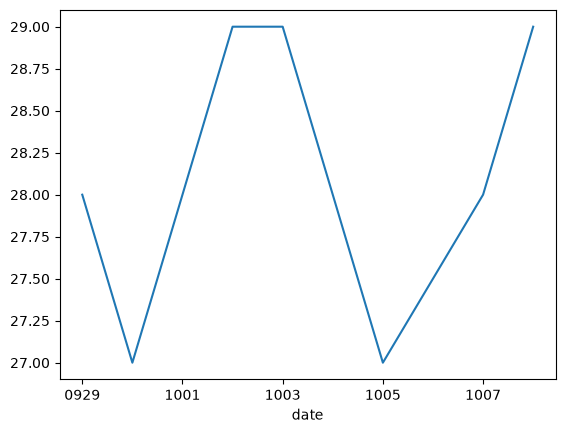

In [102]:
# if I want to create a line plot based on a series, I just invoke the "plot" method -- or better yet, ".plot.line"

df['high'].interpolate().plot.line()

<Axes: xlabel='date'>

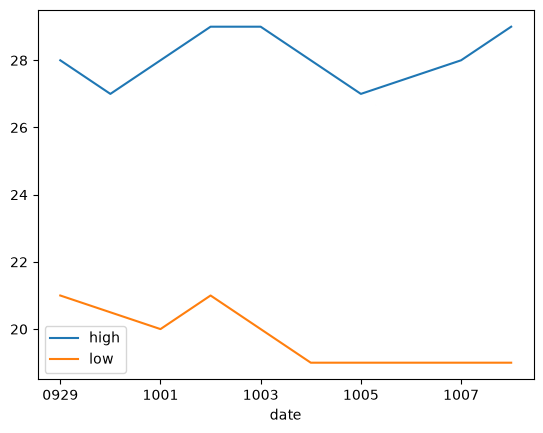

In [103]:
# what if I give it a data frame, rather than a series?

df.interpolate().plot.line()

In [104]:
# what if I don't want a line plot?
# what if I want a bar plot?

df = df.interpolate()

<Axes: xlabel='date'>

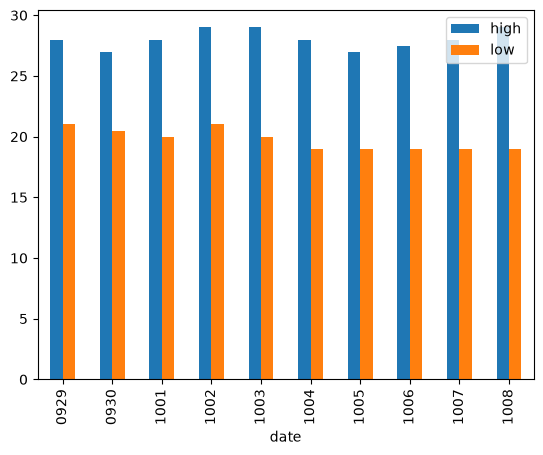

In [105]:
df.plot.bar()

<Axes: ylabel='date'>

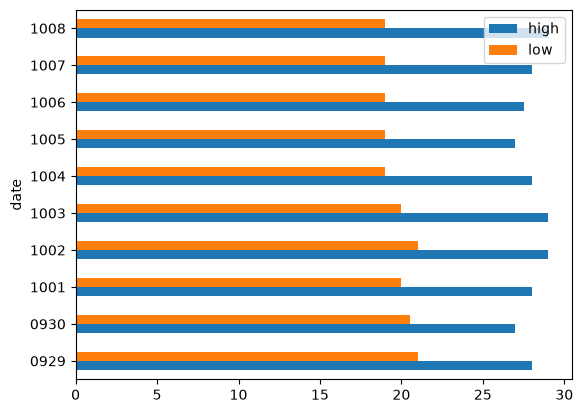

In [106]:
df.plot.barh()  # horizontal bar plot

<Axes: ylabel='Frequency'>

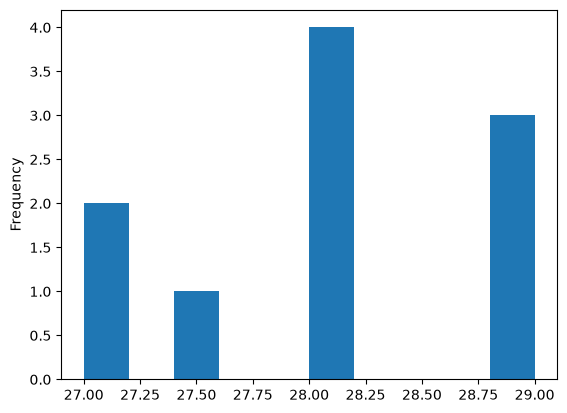

In [107]:
# histogram

df['high'].plot.hist()

In [108]:
df

,high,low
date,,
0929,28.0,21.0
0930,27.0,20.5
1001,28.0,20.0
1002,29.0,21.0
1003,29.0,20.0
1004,28.0,19.0
1005,27.0,19.0
1006,27.5,19.0
1007,28.0,19.0


<Axes: >

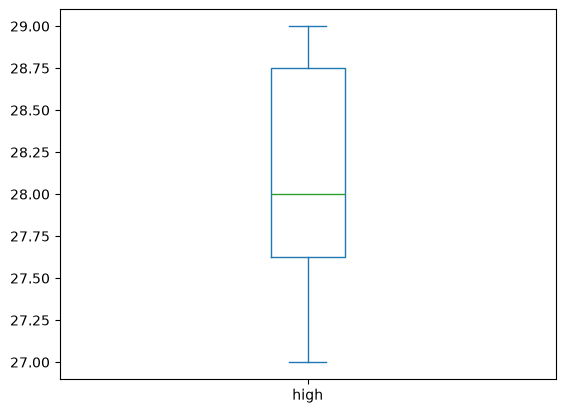

In [109]:
# if you've studied statistics, you might remember a "box and whiskers" plot or just a "box plot"

df['high'].plot.box()

In [110]:
df['high'].describe()

count    10.000000
mean     28.050000
std       0.761942
min      27.000000
25%      27.625000
50%      28.000000
75%      28.750000
max      29.000000
Name: high, dtype: float64

<Axes: >

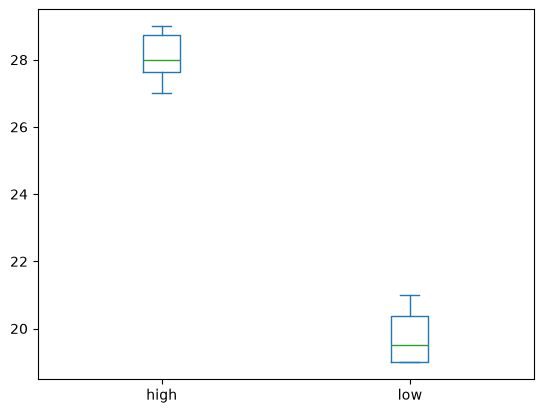

In [111]:
# get a boxplot of each column, and then you can compare their ranges

df.plot.box() 

# Exercise: Plotting practice

1. Load the Olympic data into a data frame.
2. Create a histogram for the heights of athletes.
3. Create a boxplot with the heights, weights, and ages of athletes.
4. Create a line plot showing the number of athletes at each set of games.

In [112]:
df = pd.read_csv('olympic_athlete_events.zip')

<Axes: ylabel='Frequency'>

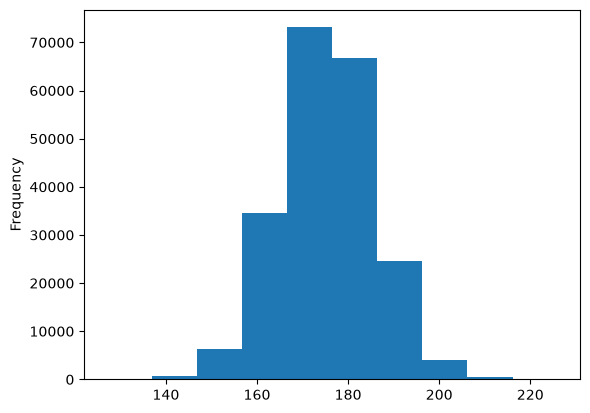

In [113]:
df['Height'].plot.hist()

In [114]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [115]:
df.tail()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN
271115,135571,Tomasz Ireneusz ya,M,34.0,185.0,96.0,Poland,POL,2002 Winter,2002,Winter,Salt Lake City,Bobsleigh,Bobsleigh Men's Four,NaN


<Axes: ylabel='Frequency'>

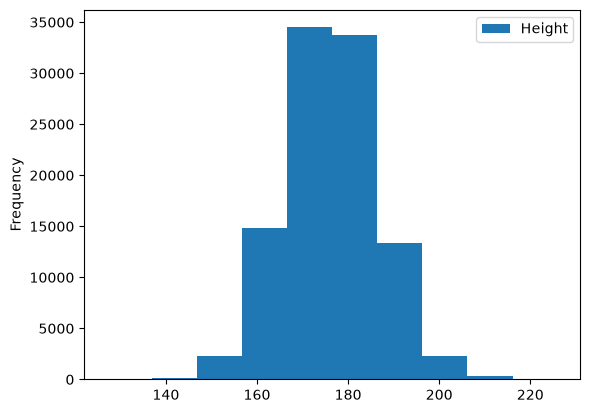

In [121]:
# how can we ensure that we're looking at unique individuals?

(
    df
    [['ID', 'Name', 'Height']]
    .dropna()
    .set_index('ID')
    .drop_duplicates()
    .plot.hist()
)

<Axes: >

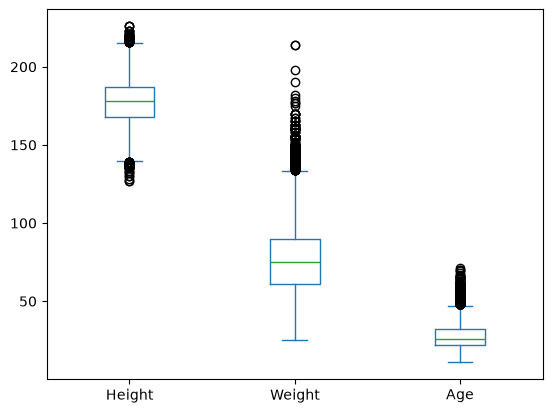

In [122]:
# Create a boxplot with the heights, weights, and ages of athletes.

(
    df
    [['ID', 'Height', 'Weight', 'Age']]
    .dropna()
    .set_index('ID')
    .drop_duplicates()
    .plot.box()
)


<Axes: xlabel='Year,Season'>

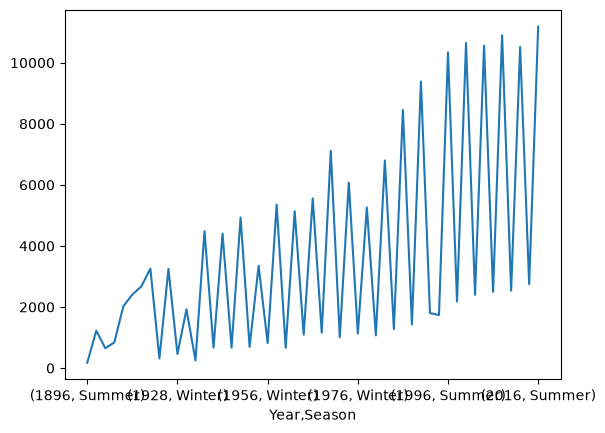

In [125]:
# Create a line plot showing the number of athletes at each set of games.

# categorical -- Year, Season
# numeric -- ID
# aggfunc -- nunique (how many unique values were there?)

(
    df
    .groupby(['Year', 'Season'])['ID'].nunique()
    .plot.line()
)

<Axes: xlabel='Year'>

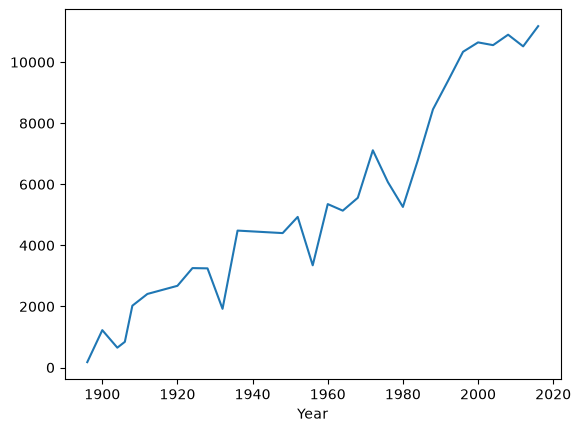

In [126]:
# only look at summer games

(
    df
    .loc[ pd.col('Season') == 'Summer' ] 
    .groupby('Year')['ID'].nunique()

    .plot.line()
)

# Scatter plot

Often, we want to know whether there is a correlation between two columns. An easy graphical way to do this is with a "scatterplot," where we take each column and put it on either the x or y axis, and then plot the x vs. the y. This can show us about correlations.


<Axes: xlabel='Height', ylabel='Weight'>

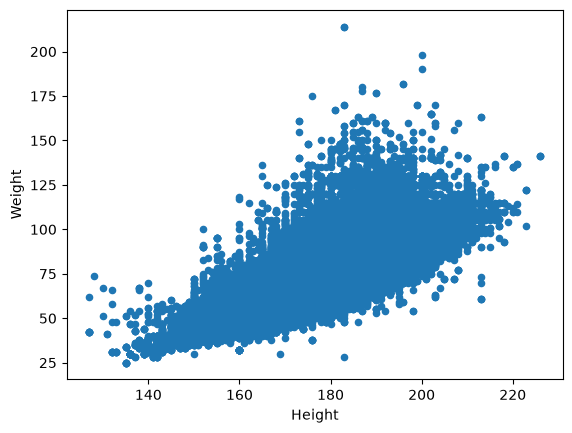

In [127]:
# is there a correlation between height and weight?

(
    df
    .plot.scatter(x='Height', y='Weight')
)

<Axes: xlabel='Height', ylabel='Weight'>

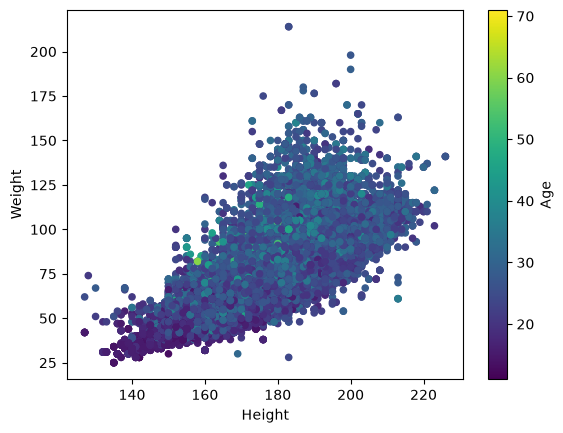

In [128]:

(
    df
    .plot.scatter(x='Height', y='Weight', c='Age')
)

In the last 2 years, I've become a big fan of the Plotly library for plotting. It is nicer and easier to work with.

In [ ]:
from plotly import express as p